In [56]:
import os 
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import scb_multiome as scbm 
import scanpy as sc 
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns 


In [57]:
BASE_DIR = "/mnt/fxcai/nfs_share2"
data_dir = "../../data"
atac_path = f"{data_dir}/atac_data/ad_atac_132k.h5ad"
rna_path = f"{data_dir}/rna_data/tfs.h5ad"
preprocess_folder_acc = f"{data_dir}/atac_data/scb_processed"
preprocess_folder_rna = f"{data_dir}/rna_data"
chippath = f"{data_dir}/chip_data/atac_132k_encode_byTF.csv"
gt_path = f"{data_dir}/chip_data/blood_gt.csv"
fimo_dir = f"{data_dir}/all_seq_match/fimo_res.csv"
spearmanr_dir = f"{data_dir}/spearmanR/SpearmanR.csv"

result_dir = "."

### read groundtruth, baseline metrics & model metrics

In [58]:
ad_atac = sc.read_h5ad(atac_path)
ad_rna = sc.read_h5ad(rna_path)
sc.pp.scale(ad_rna)

chip_bulk = pd.read_csv(chippath, index_col=0)
df_gt = pd.read_csv(gt_path, index_col=0)
act_pval = pd.read_csv(fimo_dir, index_col=0)
celltype_specific_SpearmanR = pd.read_csv(spearmanr_dir, index_col=0)

## keeping the same jaspar_motifs.index for writing gradSeq/gradTF
tfs_cts = df_gt.columns
jaspar_motifs = scbm.pp.read_JASPAR_pwms(f"{BASE_DIR}/genomes/JASPAR_human_TFs_meme/20230424043428_JASPAR2022_combined_matrices_2028_meme.txt")
jaspar_motifs = jaspar_motifs[jaspar_motifs['tf'].isin(ad_rna.var['gene_symbols'])]
jaspar_motifs = jaspar_motifs.reset_index(drop=True)
jaspar_motifs = jaspar_motifs[jaspar_motifs['tf'].isin([tf_ct.split("_")[0] for tf_ct in tfs_cts])]

In [59]:
peak_emb = pd.read_csv("./benchmark_summarize/peak_emb.csv", index_col=0)

In [60]:
## consistent with writing gradSeq/gradTF, subset peaks to >=10% acc for faster computation
print(ad_atac.shape)
peaks_select = ad_atac.var['n_cells']>0.1*ad_atac.n_obs
ad_atac = ad_atac[:, peaks_select]
print(ad_atac.shape)

celltype_specific_SpearmanR = celltype_specific_SpearmanR.loc[peaks_select,:]
act_pval = act_pval.loc[peaks_select,:]
df_gt = df_gt.loc[peaks_select,:]
chip_bulk = chip_bulk.loc[peaks_select,:]
peak_emb = peak_emb.loc[peaks_select,:]

print(celltype_specific_SpearmanR.shape, act_pval.shape, df_gt.shape, chip_bulk.shape, peak_emb.shape)

(9543, 131511)
(9543, 20889)
(20889, 13) (20889, 14) (20889, 13) (20889, 870) (20889, 32)


In [61]:
## filter out TFs without available encode data 
tfs_gt = df_gt.columns.str.split("_").str[0]
df_gt = df_gt.loc[:,tfs_gt.isin(chip_bulk.columns)]
print(df_gt.shape)

(20889, 11)


In [5]:
gradSeq, gradTF = scbm.utils.read_grads_celltype(tfs_cts=df_gt.columns, 
                                                 jaspar_motifs=jaspar_motifs,
                                                 ad_atac=ad_atac,
                                                 ad_rna=ad_rna,
                                                 _chunk_size=50)

CTCF MA1930.1


  0%|          | 0/418 [00:00<?, ?it/s]

100%|██████████| 418/418 [00:37<00:00, 11.01it/s]


classical monocytes: 1848
naive B cells: 282
CTCF MA0139.1


100%|██████████| 418/418 [00:37<00:00, 11.05it/s]


...

classical monocytes: 1848
STAT1 MA0517.1


100%|██████████| 418/418 [00:32<00:00, 13.01it/s]


classical monocytes: 1848
STAT1 MA0137.3


100%|██████████| 418/418 [00:32<00:00, 13.02it/s]


classical monocytes: 1848


In [7]:
gradSeq.to_csv("./benchmark_summarize/gradSeq_ct_specific.csv")
gradTF.to_csv("./benchmark_summarize/gradTF_ct_specific.csv")

In [62]:
gradSeq = pd.read_csv("./benchmark_summarize/gradSeq_ct_specific.csv", index_col=0)
gradTF = pd.read_csv("./benchmark_summarize/gradTF_ct_specific.csv", index_col=0)

### 1. baseline, model, extended (35) metrics, train on 1% groundtruths 

In [63]:
bm_baseline = scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                            metrics=[act_pval, celltype_specific_SpearmanR],
                                            jaspar_motifs=jaspar_motifs,
                                            chip_bulk=None)
bm_baseline.logReg_all(downsample_frac=0.01, trainOn="gt")
auprc_baseline_on_gt = bm_baseline.auprcs_to_csv()
auprc_baseline_on_gt.index = ['baseline_on_gt']

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 38.32it/s]


In [64]:
bm_std= scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                        metrics=[gradSeq, gradTF, act_pval, celltype_specific_SpearmanR],
                                        jaspar_motifs=jaspar_motifs,
                                        chip_bulk=None)
bm_std.logReg_all(downsample_frac=0.01, trainOn="gt")
auprc_std_on_gt = bm_std.auprcs_to_csv()
auprc_std_on_gt.index = ['std_on_gt']

100%|██████████| 11/11 [00:00<00:00, 24.89it/s]


In [65]:
bm_extended = scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                            metrics=[gradTF, act_pval, celltype_specific_SpearmanR, peak_emb],
                                            jaspar_motifs=jaspar_motifs,
                                            chip_bulk=None)
bm_extended.logReg_all(downsample_frac=0.01, trainOn="gt")
auprc_ext_on_gt = bm_extended.auprcs_to_csv()
auprc_ext_on_gt.index = ['ext_on_gt']

100%|██████████| 11/11 [00:02<00:00,  4.71it/s]


### 2. baseline, model, extended (35) metrics, train on non-tissue specific chip data


In [70]:
bm_baseline_noisy = scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                            metrics=[act_pval, celltype_specific_SpearmanR],
                                            jaspar_motifs=jaspar_motifs,
                                            chip_bulk=chip_bulk)
bm_baseline_noisy.logReg_all(downsample_frac=1., trainOn="chip_bulk")
auprc_baseline_on_bulk = bm_baseline_noisy.auprcs_to_csv()
auprc_baseline_on_bulk.index = ['baseline_on_bulk']


bm_std_noisy= scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                        metrics=[gradSeq, gradTF, act_pval, celltype_specific_SpearmanR],
                                        jaspar_motifs=jaspar_motifs,
                                        chip_bulk=chip_bulk)
bm_std_noisy.logReg_all(downsample_frac=1., trainOn="chip_bulk")
auprc_std_on_bulk = bm_std_noisy.auprcs_to_csv()
auprc_std_on_bulk.index = ['std_on_bulk']


bm_extended_noisy = scbm.utils.tf_act_cross_peaks(gt=df_gt, 
                                metrics=[gradTF, act_pval, celltype_specific_SpearmanR, peak_emb],
                                jaspar_motifs=jaspar_motifs,
                                chip_bulk=chip_bulk)
bm_extended_noisy.logReg_all(downsample_frac=1., trainOn="chip_bulk")
auprc_ext_on_bulk = bm_extended_noisy.auprcs_to_csv()
auprc_ext_on_bulk.index = ['ext_on_bulk']

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:11<00:00,  1.08s/it]


#### tidy auprcs result & visialize 

In [71]:
res = pd.concat([auprc_baseline_on_gt, auprc_std_on_gt, auprc_ext_on_gt,
                 auprc_baseline_on_bulk, auprc_std_on_bulk, auprc_ext_on_bulk]).T
res[:5]

,baseline_on_gt,std_on_gt,ext_on_gt,baseline_on_bulk,std_on_bulk,ext_on_bulk
CTCF:MA1930.1_classical monocytes,0.537170,0.501792,0.423096,0.555306,0.505570,0.437425
CTCF:MA0139.1_classical monocytes,0.695143,0.663194,0.524833,0.681399,0.576456,0.467558
CTCF:MA1929.1_classical monocytes,0.590588,0.571890,0.486690,0.587320,0.528980,0.440887
CTCF:MA1930.1_naive B cells,0.588069,0.591532,0.514929,0.593917,0.572927,0.535442
CTCF:MA0139.1_naive B cells,0.709125,0.713045,0.606137,0.680813,0.644769,0.562446


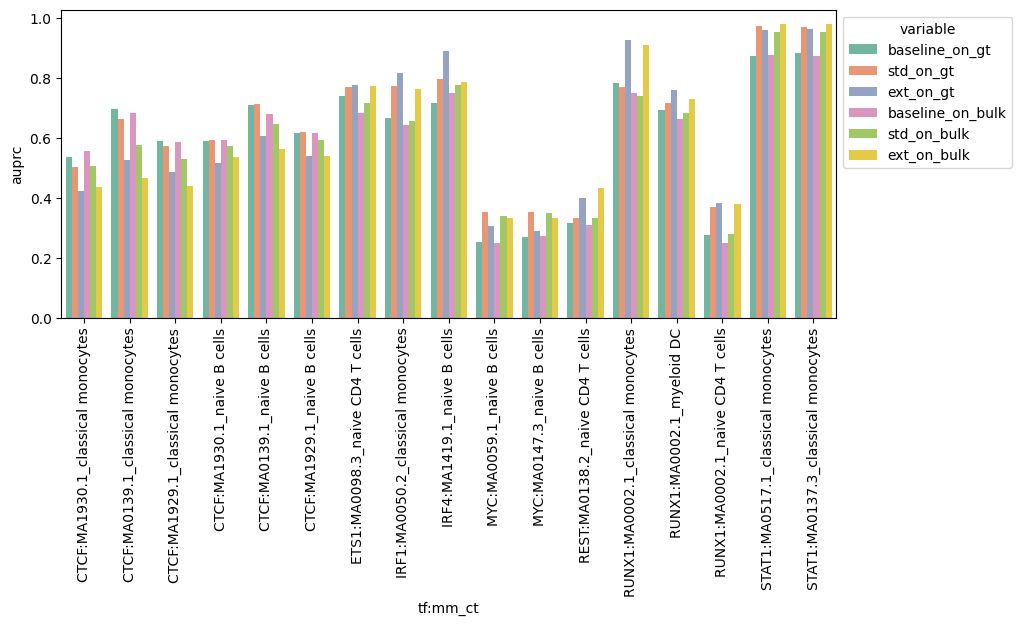

In [77]:
res['tf:mm_ct'] = res.index
res_plot = res.melt(
            value_vars=[c for c in res.columns if c != "tf:mm_ct"], 
            id_vars=['tf:mm_ct'])
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=res_plot, x = "tf:mm_ct", y="value", hue='variable', palette="Set2", ax=ax)
ax.set_ylabel("auprc")
ax.tick_params(axis='x', rotation=90)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

In [79]:
fig.savefig("./figs/auprcs.svg", dpi=300, bbox_inches='tight')